# Resonator Spectroscopy with SHFQA or SHFQC

This notebook shows you how to perform CW resonator spectroscopy in LabOne Q with a SHFQA or the quantum analyzer channels of a SHFQC. Here, you'll find the resonance frequency of the qubit readout resonator by looking at the transmission or reflection of a probe signal applied through the readout line.

A demonstration of this notebook, starting from the basics of installing LabOne Q, is also available on our Youtube channel [here](https://www.youtube.com/watch?v=aRaGHNZeVkI&list=PLjxUCNDRYw8k1_HTzXDohUHKhYKYFQrbn&index=1&ab_channel=ZurichInstruments)

## 0. LabOne Q Imports

You'll begin by importing `laboneq.simple` and some extra helper functions to run the examples. 

In [1]:
import time
from pathlib import Path

# Helpers:
from laboneq.contrib.example_helpers.generate_device_setup import (
    generate_device_setup_qubits,
)
from laboneq.contrib.example_helpers.plotting.plot_helpers import plot_results

# LabOne Q:
from laboneq.simple import *

## 1. Device Setup

Below, you'll create a device setup and choose to run this notebook in emulated mode or directly on the control hardware, by specifying `use_emulation = True/False` respectively.

If you run on your hardware, you need to generate a device setup first, please have a look at our [device setup tutorial](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/00_device_setup/tutorials/00_device_setup.html) for how to do this in general.
Here, we use a helper functions to generate the device setup and a set up qubit objects with pre-defined parameters. 

In [2]:
# specify the number of qubits you want to use
number_of_qubits = 6

# generate the device setup and the qubit objects using a helper function
device_setup, qubits = generate_device_setup_qubits(
    number_qubits=number_of_qubits,
    shfqc=[
        {
            "serial": "DEV12001",
            "number_of_channels": 6,
            "readout_multiplex": 6,
            "options": None,
        }
    ],
    include_flux_lines=False,
    server_host="localhost",
    setup_name=f"my_{number_of_qubits}_fixed_qubit_setup",
)

In [3]:
# use emulation mode - no connection to instruments
use_emulation = True

# create and connect to a session
session = Session(device_setup=device_setup)
session.connect(do_emulation=use_emulation)

[2026.06.26 13:54:18.529] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/khatran/Desktop/pico-thermometry/tune-up/laboneq_output/log
[2026.06.26 13:54:18.531] INFO    VERSION: laboneq 26.4.0
[2026.06.26 13:54:18.532] INFO    Connecting to data server at localhost:8004
[2026.06.26 13:54:18.533] INFO    Connected to Zurich Instruments LabOne Data Server version 26.04.1.6 at localhost:8004
[2026.06.26 13:54:18.535] INFO    Configuring the device setup
[2026.06.26 13:54:18.536] INFO    The device setup is configured


## 2. Experiment Parameters

Now you'll define the frequency sweep parameters to use in your experiment.

In [4]:
# frequency range of spectroscopy scan - around expected centre frequency as defined in qubit parameters
start_freq = -200.0e6
stop_freq = 200.0e6
num_points = 101
integration_time = 1e-3

# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4


# define sweep parameter
def create_readout_freq_sweep(qubit, start_freq, stop_freq, num_points):
    return LinearSweepParameter(
        uid=f"{qubit}_res_freq",
        start=start_freq,
        stop=stop_freq,
        count=num_points,
        axis_name="Frequency [Hz]",
    )

## 3. Experiment Definition

You'll now create a function which generates you CW spectroscopy [experiment](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/index.html). In this experiment, you'll pass the `LinearSweepParameter` defined previously as an argument to the [sweep section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/04_averaging_sweeping.html#parameter-sweeps). Within the section, you'll create a [section](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/03_sections_pulses/concepts/index.html) containing an `acquire` command.

In [5]:
# function that defines a resonator spectroscopy experiment, and takes the frequency sweep as a parameter


def res_spectroscopy_cw(freq_sweep, exp_settings):
    # Create resonator spectroscopy experiment - uses only readout drive and signal acquisition
    exp_spec = Experiment(
        uid="Resonator Spectroscopy",
        signals=[
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define experimental sequence
    # loop - average multiple measurements for each frequency - measurement in spectroscopy mode
    with exp_spec.acquire_loop_rt(
        uid="shots",
        count=pow(2, exp_settings["num_averages"]),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        with exp_spec.sweep(uid="res_freq", parameter=freq_sweep):
            # readout pulse and data acquisition
            with exp_spec.section(uid="spectroscopy"):
                # resonator signal readout
                exp_spec.acquire(
                    signal="acquire",
                    handle="res_spec",
                    length=exp_settings["integration_time"],
                )
            # relax time after readout - for signal processing and qubit relaxation to ground state
            with exp_spec.section(uid="relax", length=1e-6):
                exp_spec.reserve(signal="measure")
                exp_spec.reserve(signal="acquire")

    return exp_spec

### 3.1 Experiment Calibration and Signal Map

Before running the experiment, you'll need to set an [experiment calibration](https://docs.zhinst.com/labone_q_user_manual/core/functionality_and_concepts/05_experiment/concepts/00_experiment_calibration.html). The sweep parameter is assigned to the hardware oscillator modulating the readout resonator drive line. You'll also define and set the mapping between the experimental and logical lines.

In [ ]:
# function that returns the calibration of the readout line oscillator for the experimental signals


def res_spec_calib(freq_sweep):
    exp_calibration = Calibration()
    # sets the oscillator of the experimental measure signal
    # for spectroscopy, set the sweep parameter as frequency
    measure_oscillator = Oscillator(
        "readout_acquire_osc",
        frequency=freq_sweep,
    )
    exp_calibration["measure"] = SignalCalibration(oscillator=measure_oscillator)
    exp_calibration["acquire"] = SignalCalibration(oscillator=measure_oscillator)
    return exp_calibration


# signal maps for the two different qubits - maps the logical signal of the device setup to the experimental signals of the experiment


def res_spec_map(qubit):
    signal_map = {
        "measure": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "measure"
        ],
        "acquire": device_setup.logical_signal_groups[f"{qubit}"].logical_signals[
            "acquire"
        ],
    }
    return signal_map


# define the experiment with the frequency sweep relevant for qubit 0
freq_sweep = create_readout_freq_sweep("q0", start_freq, stop_freq, num_points)
exp_settings = {"integration_time": integration_time, "num_averages": num_averages}
exp_spec = res_spectroscopy_cw(freq_sweep, exp_settings)

# set signal calibration and signal map for experiment to qubit 0
exp_spec.set_calibration(res_spec_calib(freq_sweep))
exp_spec.set_signal_map(res_spec_map("q0"))

### 3.2 Compile and Generate Pulse Sheet

Now you'll compile the experiment and generate a pulse sheet.

In [7]:
# compile the experiment on the open instrument session
compiled_res_spec = session.compile(exp_spec)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet", compiled_res_spec)

[2026.06.26 13:54:18.563] INFO    Starting LabOne Q Compiler run...
[2026.06.26 13:54:18.568] INFO    Resolved modulation type of oscillator on signal: 'acquire' to Hardware
[2026.06.26 13:54:18.569] INFO    Resolved modulation type of oscillator on signal: 'measure' to Hardware
[2026.06.26 13:54:18.571] INFO    Schedule completed. [0.001 s]
[2026.06.26 13:54:18.585] INFO    Code generation completed for all AWGs. [0.013 s]
[2026.06.26 13:54:18.586] INFO    Completed compilation step 1 of 1. [0.016 s]
[2026.06.26 13:54:18.601] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 13:54:18.602] INFO      Device    AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2026.06.26 13:54:18.602] INFO     ───────────────────────────────────────────────────────────── 
[2026.06.26 13:54:18.603] INFO      shfqc_0     0         27            0           0         0  
[2026.06.26 13:54:18.603] INFO     ───────────────────────────────────────────────────────────── 
[20

/Users/khatran/Desktop/pico-thermometry/tune-up/Pulse_Sheets/Resonator_Spectroscopy_Pulse_Sheet_2026-06-26-13-54-18.html

### 3.3 Run, Save, and Plot Results

Finally, you'll run the experiment, save, and plot the results.

In [8]:
# run the compiled experiemnt
res_spec_results = session.run(compiled_res_spec)
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(res_spec_results, f"Results/{timestamp}_results.json")
print(f"File saved as Results/{timestamp}_results.json")

[2026.06.26 13:54:18.647] INFO    Starting near-time execution...
[2026.06.26 13:54:18.661] INFO    Finished near-time execution.
File saved as Results/20260626T135418_results.json


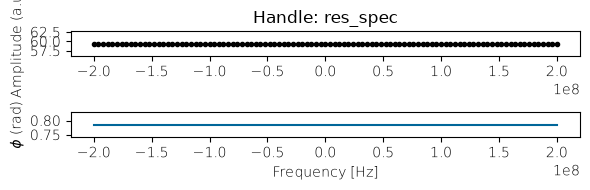

In [9]:
# plot the results
plot_results(res_spec_results, phase=True)